In [1]:
pip install requests beautifulsoup4 pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


🔗 Enter product URL:  https://www.amazon.in/dp/B09NWGYVLD/ref=sspa_dk_detail_1?psc=1&pd_rd_i=B09NWGYVLD&pd_rd_w=9yNZH&content-id=amzn1.sym.67d3dec9-3503-44a1-a945-e969d04cca69&pf_rd_p=67d3dec9-3503-44a1-a945-e969d04cca69&pf_rd_r=NSWQ935ZA99GTHDPAH65&pd_rd_wg=j7War&pd_rd_r=e7055300-1056-408a-84b7-24d21ff285f8&aref=gcgnmYc9yo&sp_csd=d2lkZ2V0TmFtZT1zcF9kZXRhaWxfdGhlbWF0aWM



📦 Product: Mackie Thrash, 15-Inch 1300W XLR Powered Loudspeaker, Black (Thrash215)
💰 Current Price: ₹35999.0

📊 15-Day Price Prediction:
      date  predicted_price
2026-04-05     35490.774276
2026-04-06     35455.461261
2026-04-07     35420.148247
2026-04-08     35384.835232
2026-04-09     35349.522218
2026-04-10     35314.209204
2026-04-11     35278.896189
2026-04-12     35243.583175
2026-04-13     35208.270160
2026-04-14     35172.957146
2026-04-15     35137.644131
2026-04-16     35102.331117
2026-04-17     35067.018102
2026-04-18     35031.705088
2026-04-19     34996.392073

🔥 BEST TIME TO BUY:
👉 Date: 2026-04-19
👉 Expected Price: ₹34996.39

📅 Weekday Analysis:
  weekday  predicted_price
   Monday     35331.865711
  Tuesday     35296.552696
Wednesday     35261.239682
 Thursday     35225.926667
   Friday     35190.613653
 Saturday     35155.300638
   Sunday     35243.583175


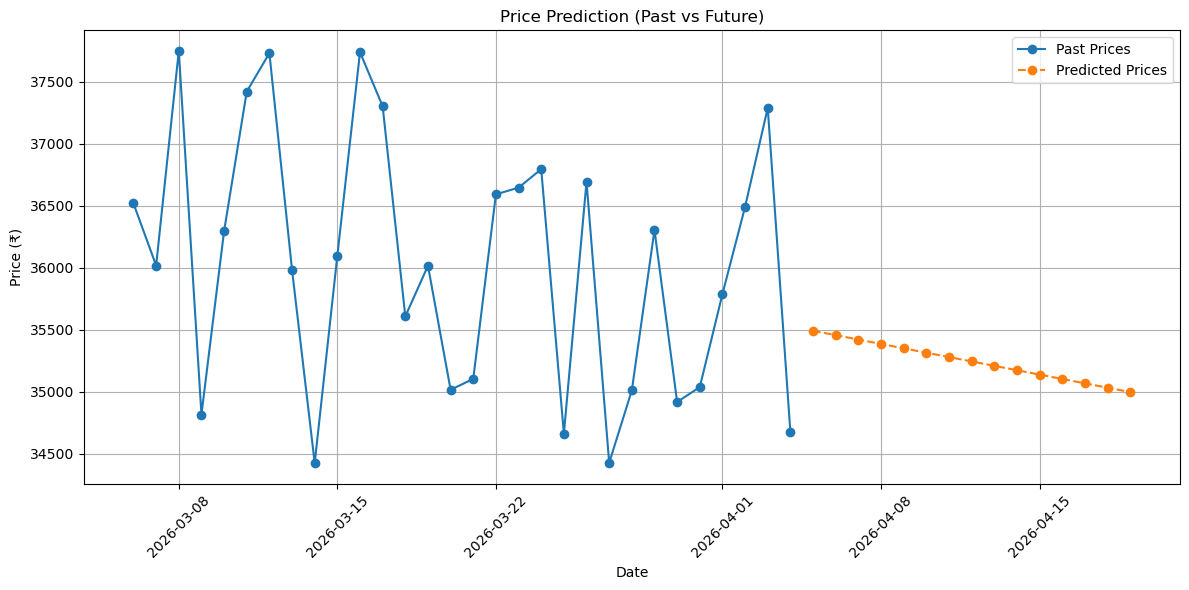

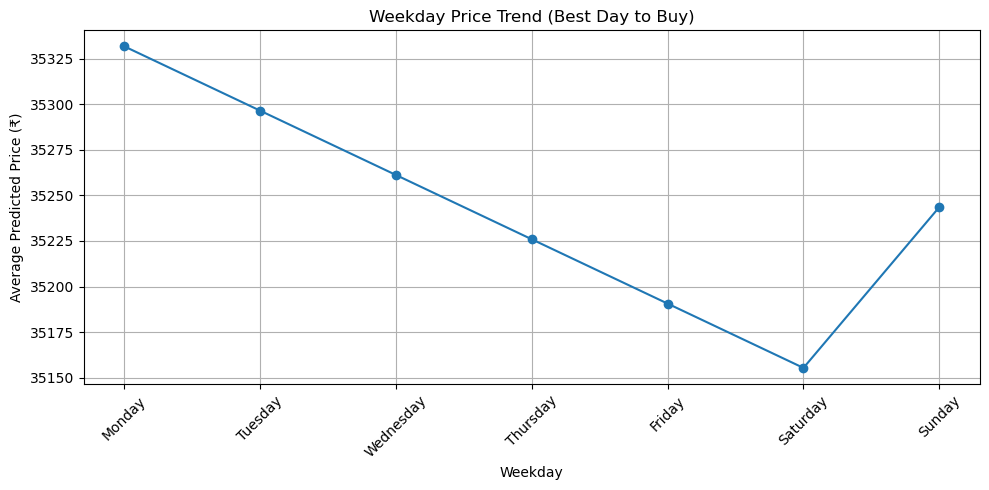

In [5]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import random
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression

# 🔑 ADD YOUR API KEY HERE
API_KEY = "8aae7c3aa8f70e0e1a42f5fe7e1385ab"


# -----------------------------
# FETCH HTML USING SCRAPERAPI
# -----------------------------
def fetch_html(url):
    api_url = "http://api.scraperapi.com"

    params = {
        "api_key": API_KEY,
        "url": url,
        "render": "true"
    }

    response = requests.get(api_url, params=params)

    if response.status_code != 200:
        print("❌ Failed to fetch page")
        return None

    return response.text


# -----------------------------
# EXTRACT PRODUCT DATA
# -----------------------------
def extract_data(html, url):
    soup = BeautifulSoup(html, "html.parser")

    name = "Unknown Product"
    price = None

    try:
        if "amazon" in url:
            name = soup.find(id="productTitle").get_text(strip=True)
            price = soup.find("span", class_="a-price-whole").get_text()

        elif "flipkart" in url:
            name = soup.find("span", class_="B_NuCI").get_text()
            price = soup.find("div", class_="_30jeq3").get_text()

        elif "myntra" in url:
            name = soup.find("h1").get_text()
            price_tag = soup.find("span", class_="pdp-price") or soup.find("span", class_="pdp-discounted-price")
            if price_tag:
                price = price_tag.get_text()
    except:
        pass

    # CLEAN PRICE
    if price:
        price = price.replace("₹", "").replace(",", "").strip()
        try:
            price = float(price)
        except:
            price = None

    return name, price


# -----------------------------
# GENERATE PAST DATA
# -----------------------------
def generate_data(current_price):
    data = []

    for i in range(30):
        date = datetime.now() - timedelta(days=30 - i)
        variation = random.uniform(-0.05, 0.05)
        price = current_price + current_price * variation

        data.append([date.strftime("%Y-%m-%d"), round(price, 2)])

    return pd.DataFrame(data, columns=["date", "price"])


# -----------------------------
# PREDICT FUTURE (15 DAYS)
# -----------------------------
def predict(df, days=15):
    df["day"] = range(len(df))

    X = df[["day"]]
    y = df["price"]

    model = LinearRegression()
    model.fit(X, y)

    future_days = list(range(len(df), len(df) + days))
    preds = model.predict(pd.DataFrame(future_days, columns=["day"]))

    future_dates = [
        (datetime.now() + timedelta(days=i)).strftime("%Y-%m-%d")
        for i in range(days)
    ]

    return pd.DataFrame({
        "date": future_dates,
        "predicted_price": preds
    })


# -----------------------------
# BEST BUY DAY
# -----------------------------
def best_day(future_df):
    min_price = future_df["predicted_price"].min()
    best = future_df.loc[future_df["predicted_price"].idxmin()]
    return best["date"], round(min_price, 2)


# -----------------------------
# WEEKDAY ANALYSIS
# -----------------------------
def weekday_analysis(future_df):
    df = future_df.copy()

    df["date"] = pd.to_datetime(df["date"])
    df["weekday"] = df["date"].dt.day_name()

    analysis = df.groupby("weekday")["predicted_price"].mean().reset_index()

    order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    analysis["weekday"] = pd.Categorical(analysis["weekday"], categories=order, ordered=True)

    return analysis.sort_values("weekday")


# -----------------------------
# PLOT PRICE GRAPH
# -----------------------------
def plot(df, future_df):
    plt.figure(figsize=(12, 6))

    df_plot = df.copy()
    future_plot = future_df.copy()

    df_plot["date"] = pd.to_datetime(df_plot["date"])
    future_plot["date"] = pd.to_datetime(future_plot["date"])

    plt.plot(df_plot["date"], df_plot["price"], marker='o', label="Past Prices")
    plt.plot(future_plot["date"], future_plot["predicted_price"],
             linestyle="dashed", marker='o', label="Predicted Prices")

    plt.xlabel("Date")
    plt.ylabel("Price (₹)")
    plt.title("Price Prediction (Past vs Future)")

    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()


# -----------------------------
# WEEKDAY GRAPH (NEW)
# -----------------------------
def plot_weekday(analysis):
    plt.figure(figsize=(10, 5))

    plt.plot(analysis["weekday"], analysis["predicted_price"], marker='o')

    plt.xlabel("Weekday")
    plt.ylabel("Average Predicted Price (₹)")
    plt.title("Weekday Price Trend (Best Day to Buy)")

    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()

    plt.show()


# -----------------------------
# MAIN
# -----------------------------
def main():
    url = input("🔗 Enter product URL: ")

    html = fetch_html(url)
    if html is None:
        return

    name, price = extract_data(html, url)

    if price is None:
        print("❌ Could not extract price")
        return

    print(f"\n📦 Product: {name}")
    print(f"💰 Current Price: ₹{price}")

    df = generate_data(price)
    future_df = predict(df, days=15)

    # TABLE
    print("\n📊 15-Day Price Prediction:")
    print(future_df.to_string(index=False))

    # BEST DAY
    best_date, min_price = best_day(future_df)
    print("\n🔥 BEST TIME TO BUY:")
    print(f"👉 Date: {best_date}")
    print(f"👉 Expected Price: ₹{min_price}")

    # WEEKDAY ANALYSIS
    analysis = weekday_analysis(future_df)
    print("\n📅 Weekday Analysis:")
    print(analysis.to_string(index=False))

    # GRAPHS
    plot(df, future_df)
    plot_weekday(analysis)


# RUN
if __name__ == "__main__":
    main()